# Get WCRP ∆lnLWP estimate
Calculated with values originally from Bellouin et al. 2020 paper using estimates of ∆ln(cloud LWP)/∆lnNd and ∆ln(cloud fraction)/∆lnNd and assuming cloud LWP * cloud fraction = total LWP)

In [1]:
from matplotlib.pyplot import *
from numpy import *
from scipy.stats import binned_statistic, binned_statistic_2d
import numpy as np
#import xarray as xr
%matplotlib inline

[]

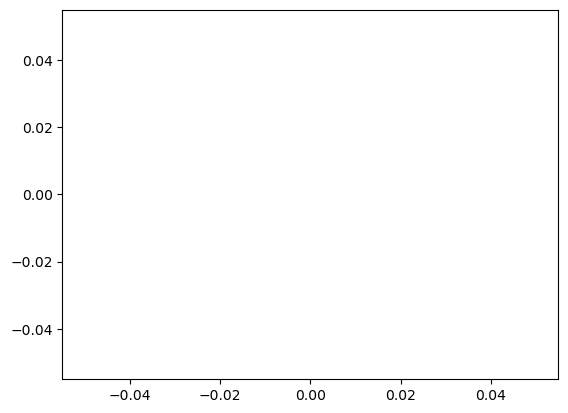

In [2]:
plot()

In [3]:
def LWPfromadj(dlnLdlnN,dlnCdlnN,C=0.22):
    #Cliq=0.22 page 25 of bellouin
    #dlncdlnN=(1/C)*dCdlnN
    dlnLWPdlnN=dlnLdlnN+dlnCdlnN ## might be typo and both are log quantities page 26 of Bellouin
    return dlnLWPdlnN

In [4]:
ranL=[-0.36,-0.011]
mnL=mean(ranL); sigL=float(diff(ranL)/2);
print(mnL,sigL)
ranC=[0,0.1]
mnC=mean(ranC); sigC=float(diff(ranC)/2);
ranlNd=[0.05,0.17]
mnN=mean(ranlNd); sigN=float(diff(ranlNd)/2);

intc=1.98
dlnLdlnN=linspace(mnL-intc*sigL,mnL+intc*sigL,110)
dlnCdlnN=linspace(mnC-intc*sigC,mnC+intc*sigC,105)
dlnLWPdlnN=zeros((len(dlnLdlnN),len(dlnCdlnN)))*NaN
for i in range(dlnLWPdlnN.shape[0]):
    for j in range(dlnLWPdlnN.shape[1]):
        dlnLWPdlnN[i,j]=LWPfromadj( dlnLdlnN[i],dlnCdlnN[j])
print(dlnLWPdlnN.shape,dlnLdlnN.shape,dlnCdlnN.shape)

-0.1855 0.1745
(110, 105) (110,) (105,)


/glade/derecho/scratch/jnug/tmp/ipykernel_61668/4085629742.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mnL=mean(ranL); sigL=float(diff(ranL)/2);
/glade/derecho/scratch/jnug/tmp/ipykernel_61668/4085629742.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mnC=mean(ranC); sigC=float(diff(ranC)/2);
/glade/derecho/scratch/jnug/tmp/ipykernel_61668/4085629742.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mnN=mean(ranlNd); sigN=float(diff(ranlNd)/2);


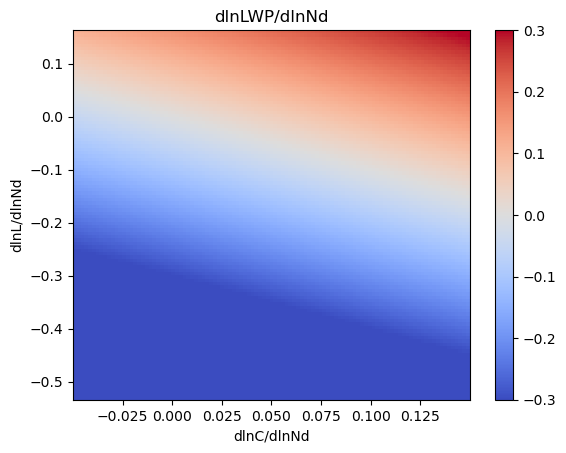

In [5]:
pcolormesh(dlnCdlnN,dlnLdlnN,dlnLWPdlnN,cmap='coolwarm',vmin=-0.3,vmax=0.3)
xlabel('dlnC/dlnNd')
ylabel('dlnL/dlnNd')
title('dlnLWP/dlnNd')
colorbar()

In [6]:
from numpy import random
N=int(1e7)
LND=random.normal(loc=mnL, scale=sigL, size=N)
CND=random.normal(loc=mnC, scale=sigC, size=N)
NND=random.normal(loc=mnN, scale=sigN, size=N)

LWPND=LWPfromadj(LND,CND)
rangeLWPND=[-0.25,0.5]
IND=(LWPND<max(rangeLWPND))&(LWPND>min(rangeLWPND))


Text(0.5, 1.0, 'dlnLWP/dlnN')

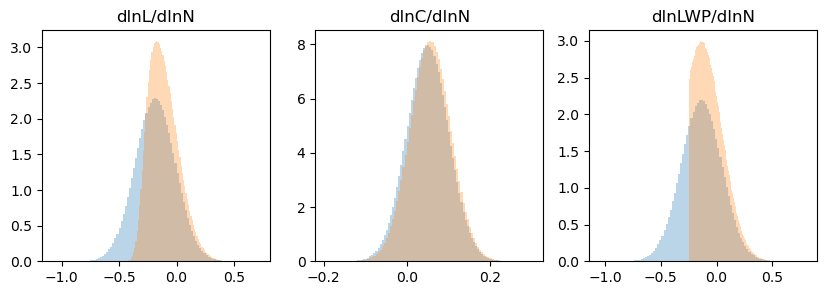

In [7]:
aa=0.3
figure(figsize=(10,3))
subplot(1,3,1)
hist(LND,bins=100,density=True,alpha=aa)
hist(LND[IND],bins=100,density=True,alpha=aa)
title('dlnL/dlnN')
subplot(1,3,2)
hist(CND,bins=100,density=True,alpha=aa)
hist(CND[IND],bins=100,density=True,alpha=aa)
title('dlnC/dlnN')
subplot(1,3,3)
hist(LWPND,bins=100,density=True,alpha=aa)
hist(LWPND[IND],bins=100,density=True,alpha=aa)
title('dlnLWP/dlnN')

[0.04703549 0.14110648]


(-0.1, 0.2)

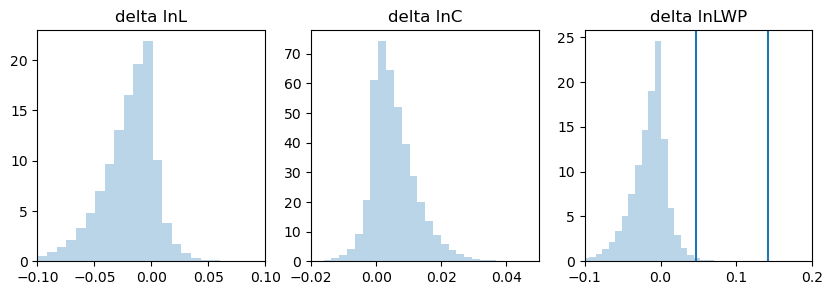

In [27]:
dLWP=LWPND*NND
dL=LND*NND
dC=CND*NND
nb=50
#rangedLWP=[0,1] ### WHATEVER AUGUST GOT FROM THE PPE scaled by the range ∆lnNd from Bellouin
mnLWP=exp(3.75) ## ln(lwp) in Augusts stuff
dlwpcons=[2,6]
dlnLWP=dlwpcons/mnLWP
print(dlnLWP)
rangedLWP=dlnLWP
# IND=(dLWP<max(rangedLWP))&(dLWP>min(rangedLWP))
aa=0.3
figure(figsize=(10,3))
subplot(1,3,1)
hist(dL,bins=nb,density=True,alpha=aa)
#hist(dL[IND],bins=100,density=True,alpha=aa)
xlim(-0.1,0.1)
title('delta lnL')
subplot(1,3,2)
hist(dC,bins=nb,density=True,alpha=aa)
#hist(dC[IND],bins=100,density=True,alpha=aa)
title('delta lnC')
xlim(-0.02,0.05)
subplot(1,3,3)
hist(dLWP,bins=nb,density=True,alpha=aa)
#hist(dLWP[IND],bins=100,density=True,alpha=aa)
axvline(rangedLWP[0])
axvline(rangedLWP[1])
title('delta lnLWP')
xlim(-0.1,0.2)


### Get the confidence intervals - JMN added
Use the calculated dLWP (delta ln(LWP)) from above

In [28]:
ci95 = [mean(dLWP)-1.96*std(dLWP), mean(dLWP)+1.96*std(dLWP)]
ci90 = [mean(dLWP)-1.645*std(dLWP), mean(dLWP)+1.645*std(dLWP)]

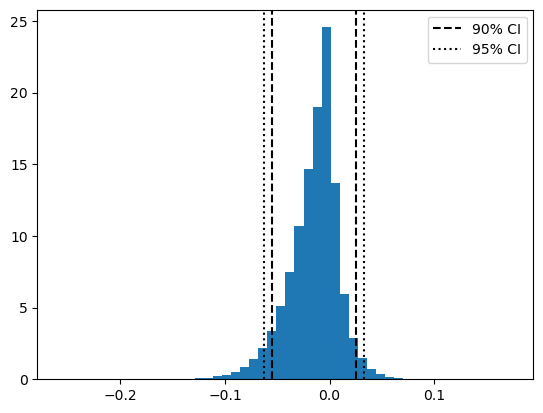

In [29]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.hist(dLWP, bins=50, density=True)
ax.axvline(ci90[0], color="k", ls="--", label="90% CI")
ax.axvline(ci90[1], color="k", ls="--")#, label="90% CI")
ax.axvline(ci95[0], color="k", ls=":", label="95% CI")
ax.axvline(ci95[1], color="k", ls=":")#, label="95% CI")
ax.legend()
plt.show()


In [31]:
import pickle
wcrp_dict_pickle = "/glade/u/home/jnug/work/multi_PPE_data/pickle_jar/WCRP_delta_lnLWP_CI.pickle"

wcrp_dict = {
    "90%": ci90,
    "95%": ci95
}

with open(wcrp_dict_pickle, 'wb') as handle:
    pickle.dump(wcrp_dict, handle)
    

In [2]:
wcrp_dict_pickle = "/glade/u/home/jnug/work/multi_PPE_data/pickle_jar/WCRP_delta_lnLWP_CI.pickle"
with open(wcrp_dict_pickle, 'rb') as handle:
    wcrp_dict = pickle.load(handle)
wcrp_dict

{'90%': [-0.05463103356270392, 0.024820203527767162],
 '95%': [-0.06223806690115328, 0.03242723686621652]}